# NBA Player Replacement Tool
**Course:** CSCA 5632 Unsupervised Algorithms in Machine Learning Final Project  
**Dataset:** [NBA Players Data (Kaggle)](https://www.kaggle.com/datasets/justinas/nba-players-data)

**GitHub Link:** https://github.com/niliacklein33/usl-final-nba-player-replacement

## Problem
When a key player gets injured or traded, front offices need to move fast. 
The question isn't just "find a good player". It's "find a player who fills 
the same statistical role." A team that loses its starting point guard needs 
a replacement who distributes, pushes pace, and doesn't need the ball in his 
hands to be effective. A team that loses a floor-spacing big man needs someone who 
can shoot from the perimeter and protect the rim.

This tool solves that problem using two unsupervised approaches:
1. **K-Means Clustering**:classifies every player into a statistical archetype, 
   so you immediately know what *type* of player you're replacing
2. **NMF Similarity Recommender**: finds the players whose complete statistical 
   profile most closely matches the one you lost

## Why Unsupervised?
There are no labels here. No one has definitively categorized every NBA player 
into a role and even if they had, those labels would be subjective. Unsupervised 
learning lets the data define the archetypes and similarities on its own terms.

## Core Question
*Given a player lost to injury or trade, which available players are their 
closest statistical replacements and what archetype are we actually trying to fill?*

## Approach
1. **EDA**: Explore and clean the dataset, visualize feature distributions and correlations
2. **K-Means Clustering**: Discover player archetypes based on performance stats
3. **NMF-based Recommender**: Build a player similarity system using matrix factorization
4. **Comparison & Conclusions**: Evaluate and interpret both models

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/justinas/nba-players-data/all_seasons.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cosine

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load data
df = pd.read_csv('/kaggle/input/datasets/justinas/nba-players-data/all_seasons.csv', index_col=0)
print(df.shape)
df.head()

(12844, 21)


,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


## Exploratory Data Analysis (EDA)

In [5]:
#Initial look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Shape: (12844, 21)

Columns: ['player_name', 'team_abbreviation', 'age', 'player_height', 'player_weight', 'college', 'country', 'draft_year', 'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season']

Data Types:
 player_name           object
team_abbreviation     object
age                  float64
player_height        float64
player_weight        float64
college               object
country               object
draft_year            object
draft_round           object
draft_number          object
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                object
dtype: object

Missing Values:
 player_name             0
team_abbreviation       0
age         

,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000
mean,27.045313,200.555097,100.263279,51.154158,8.212582,3.558486,1.824681,-2.226339,0.054073,0.140646,0.184641,0.513138,0.131595
std,4.339211,9.111090,12.426628,25.084904,6.016573,2.477885,1.800840,12.665124,0.043335,0.062513,0.053545,0.101724,0.094172
min,18.000000,160.020000,60.327736,1.000000,0.000000,0.000000,0.000000,-250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,193.040000,90.718400,31.000000,3.600000,1.800000,0.600000,-6.400000,0.021000,0.096000,0.149000,0.482000,0.066000
50%,26.000000,200.660000,99.790240,57.000000,6.700000,3.000000,1.200000,-1.300000,0.040000,0.130500,0.181000,0.525000,0.103000
75%,30.000000,208.280000,108.862080,73.000000,11.500000,4.700000,2.400000,3.200000,0.083000,0.179000,0.217000,0.563000,0.179000
max,44.000000,231.140000,163.293120,85.000000,36.100000,16.300000,11.700000,300.000000,1.000000,1.000000,1.000000,1.500000,1.000000


In [6]:
#Filter & Select Features
# Focus on one season for clustering (most recent), keep multi-season for recommender
df_recent = df[df['season'] == df['season'].max()].copy()

# Core per-game stats we'll use for modeling
feature_cols = [
    'age', 'player_height', 'player_weight',
    'gp',       # games played
    'pts',      # points
    'reb',      # rebounds
    'ast',      # assists
    'net_rating',
    'oreb_pct', # offensive rebound %
    'dreb_pct', # defensive rebound %
    'usg_pct',  # usage rate
    'ts_pct',   # true shooting %
    'ast_pct'   # assist %
]

df_model = df_recent[['player_name', 'team_abbreviation'] + feature_cols].dropna()
print(f"Players for modeling: {len(df_model)}")
df_model.head()

Players for modeling: 539


,player_name,team_abbreviation,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
12305,Quentin Grimes,NYK,23.0,195.58,95.254320,71,11.3,3.2,2.1,4.4,0.022,0.085,0.142,0.619,0.096
12306,Quenton Jackson,WAS,24.0,195.58,78.471416,9,6.2,0.9,1.7,-6.7,0.014,0.044,0.164,0.542,0.155
12307,Pat Connaughton,MIL,30.0,195.58,94.800728,61,7.6,4.6,1.3,3.4,0.033,0.144,0.133,0.531,0.069
12308,RJ Barrett,NYK,23.0,198.12,97.068688,73,19.6,5.0,2.8,-1.2,0.023,0.121,0.256,0.531,0.124
12309,Precious Achiuwa,TOR,23.0,203.20,102.058200,55,9.2,6.0,0.9,-1.6,0.083,0.213,0.190,0.554,0.063


IndexError: index 12 is out of bounds for axis 0 with size 12

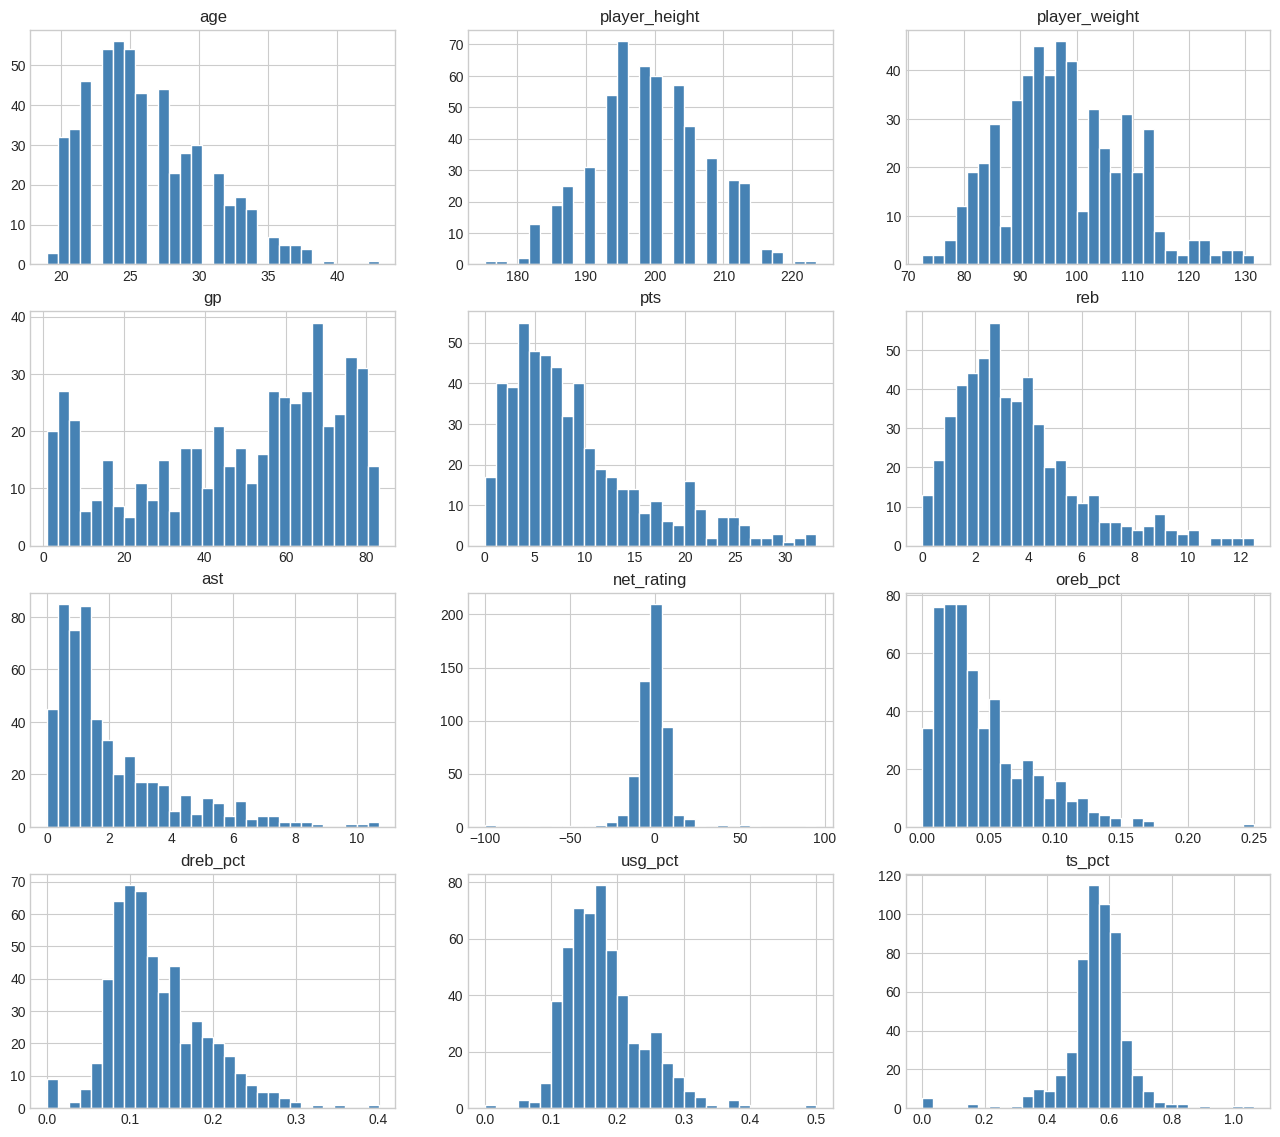

In [7]:
#Feature distributions
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df_model[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions (Most Recent Season)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

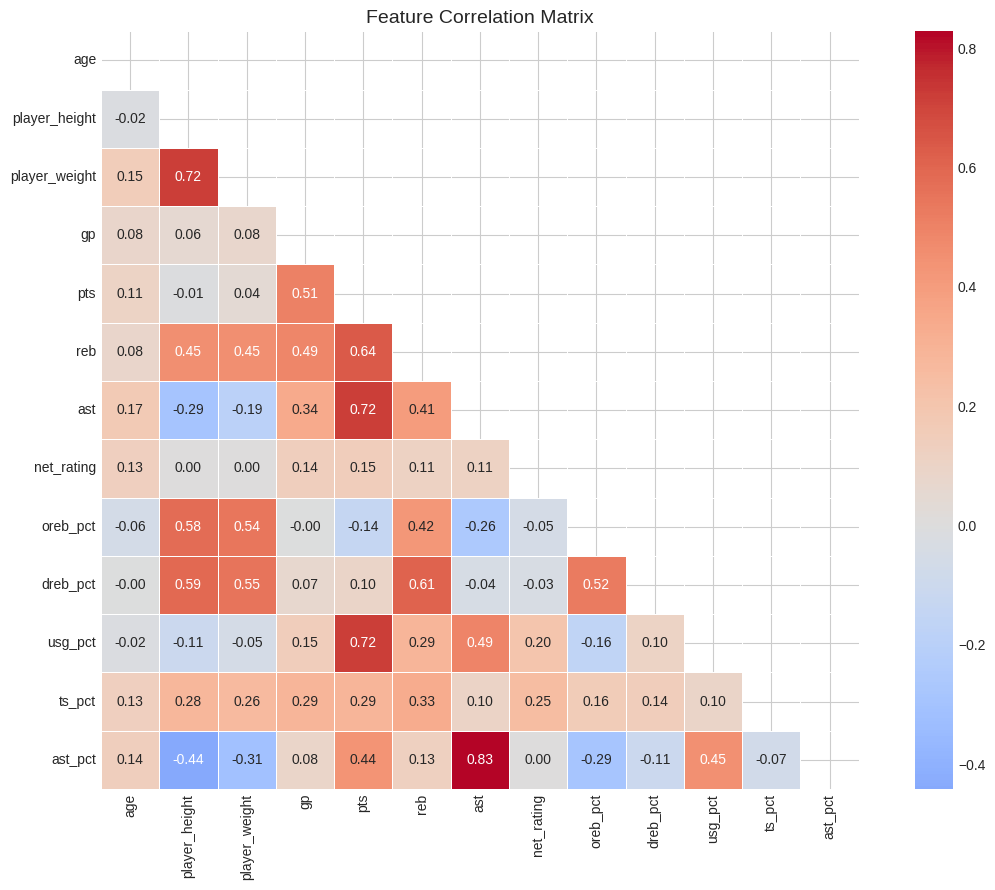

In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df_model[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

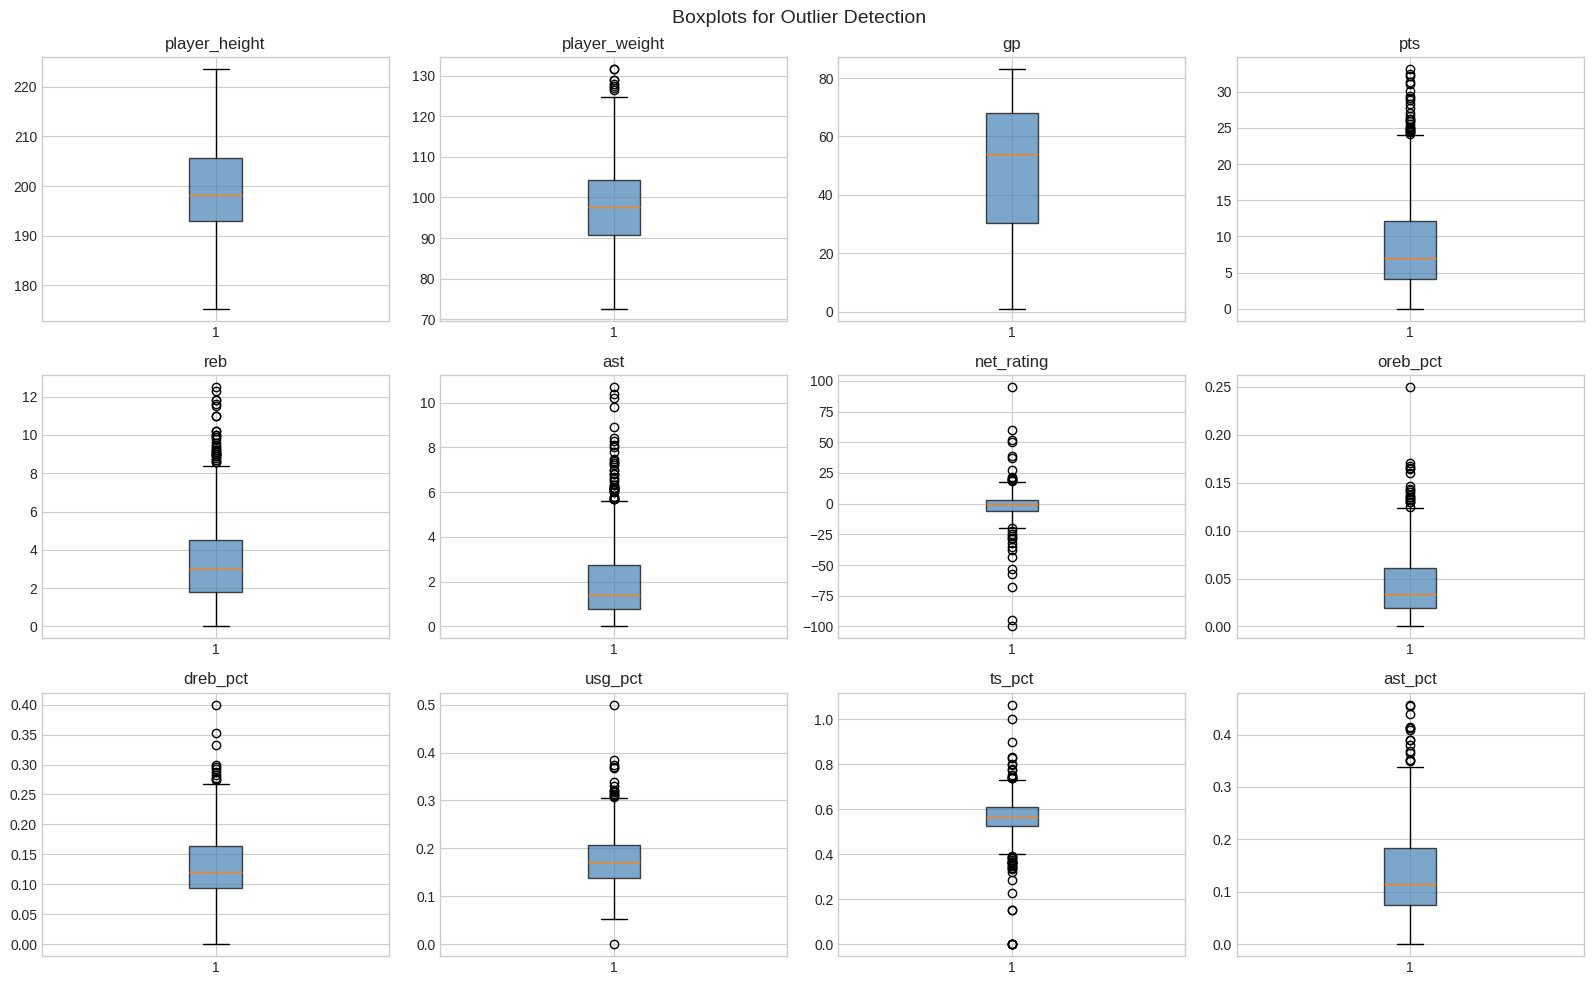


Scaling Note: Features like pts, reb, ast are on very different scales than 
percentages (ts_pct, usg_pct). We will apply StandardScaler before clustering 
to prevent high-magnitude features from dominating distance calculations.



In [10]:
#Outlier check & scaling 

# Boxplots to spot outliers
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols[1:]):  # skip age
    axes[i].boxplot(df_model[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)

plt.suptitle('Boxplots for Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

print("""
Scaling Note: Features like pts, reb, ast are on very different scales than 
percentages (ts_pct, usg_pct). We will apply StandardScaler before clustering 
to prevent high-magnitude features from dominating distance calculations.
""")

In [11]:
#Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(df_model[feature_cols])
X_df = pd.DataFrame(X, columns=feature_cols, index=df_model.index)
print("Scaled feature matrix shape:", X_df.shape)

Scaled feature matrix shape: (539, 13)


## Model 1: K-Means Clustering / Player Archetypes

K-Means partitions players into k clusters by minimizing intra-cluster variance.
We'll use two methods to find the optimal k:
- **Elbow Method**: look for the "elbow" in inertia (within-cluster sum of squares)
- **Silhouette Score**: measures how well-separated clusters are (higher = better)

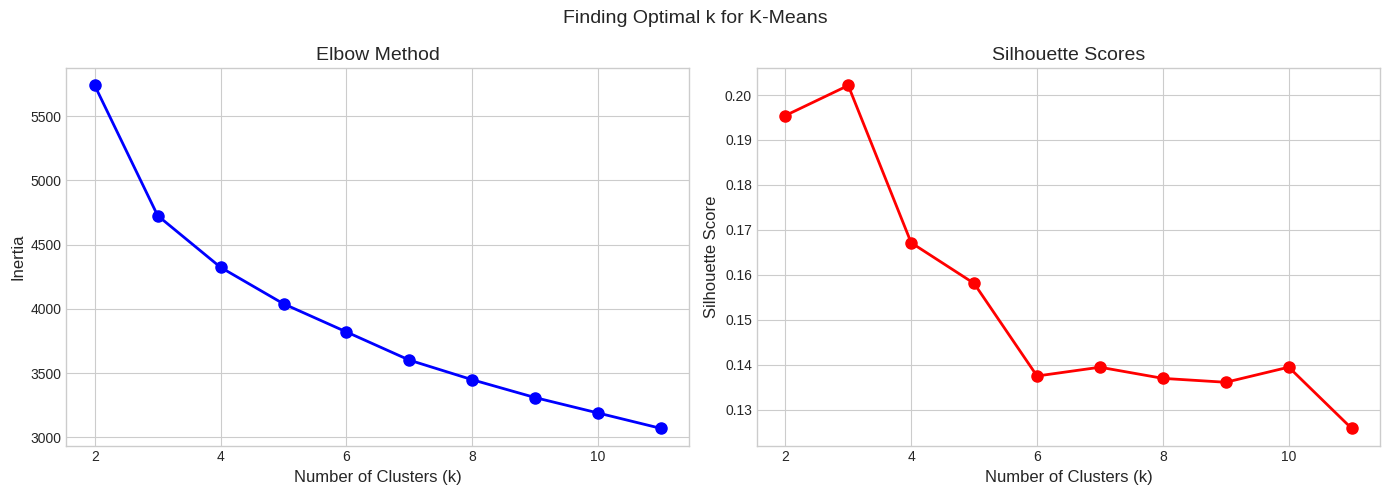

k=2: silhouette=0.1954
k=3: silhouette=0.2021
k=4: silhouette=0.1672
k=5: silhouette=0.1581
k=6: silhouette=0.1375
k=7: silhouette=0.1395
k=8: silhouette=0.1370
k=9: silhouette=0.1361
k=10: silhouette=0.1395
k=11: silhouette=0.1259


In [13]:
#Elbow method & silhouette scores
inertias = []
silhouette_scores = []
k_range = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Scores', fontsize=14)

plt.suptitle('Finding Optimal k for K-Means', fontsize=14)
plt.tight_layout()
plt.show()

# Print scores
for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette={s:.4f}")


### Choosing k
The silhouette score peaks at k=3 (0.202), suggesting the most statistically 
distinct separation occurs with 3 clusters. However, the elbow curve flattens 
gradually around k=5, and k=3 produces overly broad groupings. We select **k=5** 
to balance statistical validity with basketball interpretability, allowing us to 
distinguish more nuanced archetypes (ex. separating playmaking guards from 
3-and-D wings, which k=3 merges into one group).


In [14]:
#Fit Final K-Means model
# Fit final model with chosen k
K_OPTIMAL = 5  # adjust based on your plots

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_model['cluster'] = kmeans.fit_predict(X)

print("Cluster distribution:")
print(df_model['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0     49
1    109
2    195
3     84
4    102
Name: count, dtype: int64


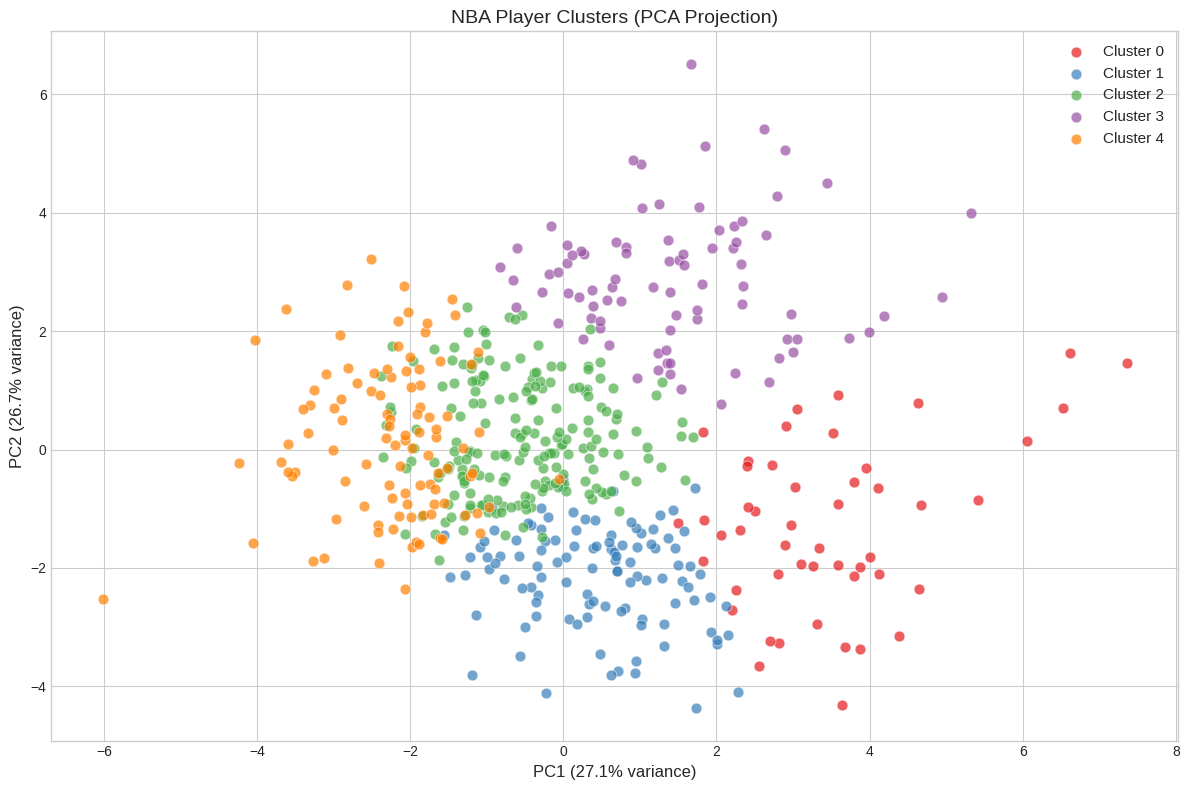

In [15]:
#Visualize Clusters with PCA
# Reduce to 2D with PCA for visualization
pca_viz = PCA(n_components=2, random_state=42)
X_2d = pca_viz.fit_transform(X)

df_model['pca1'] = X_2d[:, 0]
df_model['pca2'] = X_2d[:, 1]

plt.figure(figsize=(12, 8))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2',
                  3: 'Cluster 3', 4: 'Cluster 4'}  # we'll rename after interpreting

for cluster_id in range(K_OPTIMAL):
    mask = df_model['cluster'] == cluster_id
    plt.scatter(df_model.loc[mask, 'pca1'],
                df_model.loc[mask, 'pca2'],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.7, s=60, edgecolors='white', linewidths=0.5)

plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('NBA Player Clusters (PCA Projection)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [17]:
#Interpret Cluster Profiles
# Mean stats per cluster — this is how we label the archetypes
cluster_profile = df_model.groupby('cluster')[feature_cols].mean().round(2)
print(cluster_profile.T)  # transposed for readability

cluster             0       1       2       3       4
age             26.24   26.50   26.62   27.27   23.91
player_height  209.63  207.49  196.93  193.83  194.43
player_weight  113.12  107.59   95.27   92.27   89.51
gp              64.65   40.78   57.02   61.01   19.97
pts             15.38    5.35    8.33   19.31    3.26
reb              8.76    3.60    2.86    4.60    1.42
ast              2.74    0.83    1.65    5.44    1.10
net_rating       1.33   -2.75    0.54    0.79   -7.60
oreb_pct         0.09    0.08    0.03    0.02    0.03
dreb_pct         0.22    0.18    0.10    0.12    0.11
usg_pct          0.20    0.15    0.16    0.25    0.16
ts_pct           0.62    0.60    0.58    0.57    0.44
ast_pct          0.14    0.08    0.11    0.26    0.15


* Cluster 0: Tall/heavy (209cm, 113kg), high rebounds (8.76), decent pts (15.38), high oreb/dreb, low ast. → Power Forward / Center
* Cluster 1: Tall-ish, moderate everything, negative net rating (-2.75), low pts (5.35), low gp (40). → Backup Big / Fringe Roster
* Cluster 2: Average height/weight, moderate pts (8.33), low everything else, most players (195). → Role Player / Bench Wing
* Cluster 3: High pts (19.31), high ast (5.44), high usg_pct (0.25), high ast_pct (0.26), positive net rating. → Star Playmaker / Primary Ball Handler
* Cluster 4: Youngest (23.91), fewest games (19.97), lowest pts (3.26), worst ts_pct (0.44), worst net rating (-7.60). → Young/Developmental Player

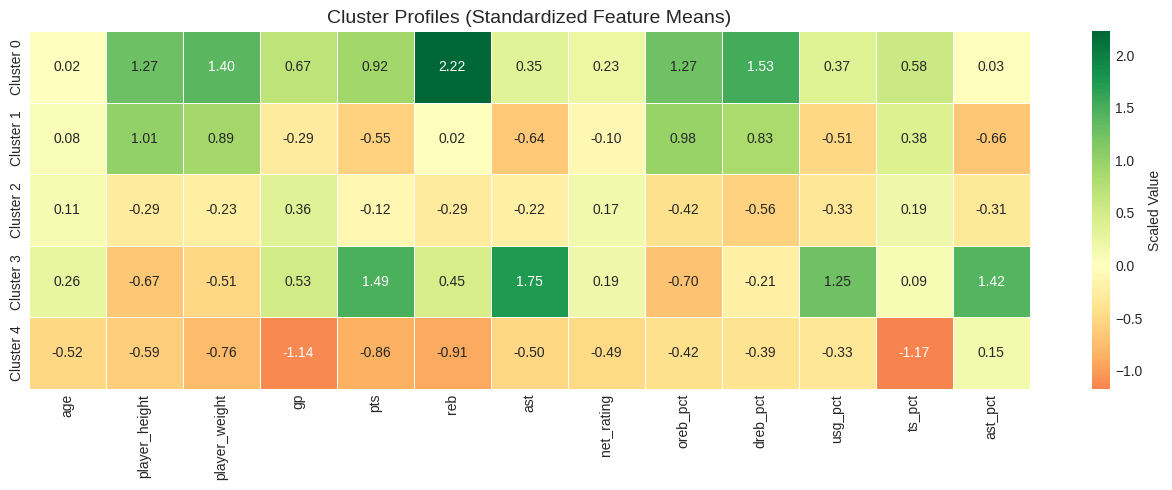

In [18]:
#Heatmap of cluster profiles
# Normalize cluster centers for clean heatmap visualization
profile_scaled = pd.DataFrame(
    scaler.transform(cluster_profile),
    columns=feature_cols,
    index=[f'Cluster {i}' for i in range(K_OPTIMAL)]
)

plt.figure(figsize=(13, 5))
sns.heatmap(profile_scaled, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'label': 'Scaled Value'})
plt.title('Cluster Profiles (Standardized Feature Means)', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
#Label & Sample Players per Cluster
# After reviewing cluster_profile above, assign meaningful archetype names
# These are placeholder names — update based on what YOUR data shows
archetype_names = {
    0: 'Power Forward / Center',
    1: 'Backup Big / Fringe Roster',
    2: 'Role Player / Bench Wing',
    3: 'Star Playmaker / Primary Ball Handler',
    4: 'Young / Developmental Player'
}

df_model['archetype'] = df_model['cluster'].map(archetype_names)

# Show sample players per archetype
print("=== Sample Players by Archetype ===\n")
for cluster_id, name in archetype_names.items():
    players = df_model[df_model['cluster'] == cluster_id]['player_name'].values[:8]
    print(f"[{name}]: {', '.join(players)}\n")

=== Sample Players by Archetype ===

[Power Forward / Center]: RaiQuan Gray, Paolo Banchero, Rudy Gobert, Robert Williams III, Naz Reid, Myles Turner, Mitchell Robinson, Onyeka Okongwu

[Backup Big / Fringe Roster]: Precious Achiuwa, Paul Reed, Richaun Holmes, Rudy Gay, Robin Lopez, Montrezl Harrell, Nathan Knight, Moussa Diabate

[Role Player / Bench Wing]: Quentin Grimes, Pat Connaughton, Patrick Beverley, Patty Mills, Patrick Williams, Raul Neto, Payton Pritchard, Reggie Bullock

[Star Playmaker / Primary Ball Handler]: RJ Barrett, Paul George, Pascal Siakam, Russell Westbrook, Monte Morris, Mike Conley, Mikal Bridges, Scottie Barnes

[Young / Developmental Player]: Quenton Jackson, R.J. Hampton, Peyton Watson, Patrick Baldwin, Saben Lee, Ryan Rollins, Ryan Arcidiacono, Ricky Rubio



### K-Means Results & Interpretation

Five clusters emerged, each mapping cleanly onto a recognizable NBA role:

| Cluster | Archetype | Key Characteristics |
|---------|-----------|---------------------|
| 0 | Power Forward / Center | Tallest and heaviest (209cm, 113kg). Leads in rebounds and oreb/dreb rates. Scoring is secondary. |
| 1 | Backup Big / Fringe Roster | Similar size to Cluster 0, but far fewer games (40 gp), low production, and negative net rating. |
| 2 | Role Player / Bench Wing | The largest group (195 players). Average across the board — the league's interchangeable depth pieces. |
| 3 | Star Playmaker / Primary Ball Handler | The clearest cluster. Highest pts (19.31), assists (5.44), usage, and ast_pct. Positive net rating. These are the guys teams are built around. |
| 4 | Young / Developmental Player | Youngest (23.9 avg), fewest games (19.97), lowest efficiency. Still earning minutes. |

The PCA projection captures 53.8% of variance. Clusters 0 and 3 separate cleanly with distinct stat profiles. Clusters 1, 2, and 4 overlap more, which makes sense because the line between a backup big and a bench wing isn't always obvious in raw stats.

### Limitations
* K-Means assumes spherical, evenly-sized clusters, a poor fit when Cluster 2 has 195 players and Cluster 0 has 49.
* The modest silhouette scores (peak 0.202) reflect that NBA skill is a continuous spectrum, not discrete buckets.
* Boundary cases, like a scoring center or a young star, will get misclassified. A soft clustering approach like GMM would handle those edge cases better.

## Model 2: NMF-Based Player Similarity Recommender

K-Means assigned players to discrete archetypes. But what if you want to find the 
five most statistically similar players to a given player, for trade targets, 
injury replacements, or roster construction?

Non-negative Matrix Factorization (NMF) decomposes the player-stats matrix into 
latent factors that capture underlying skill dimensions. We then use cosine similarity 
on the learned player representations to build a recommender.

The core question: **given a player, who are their statistical twins?**

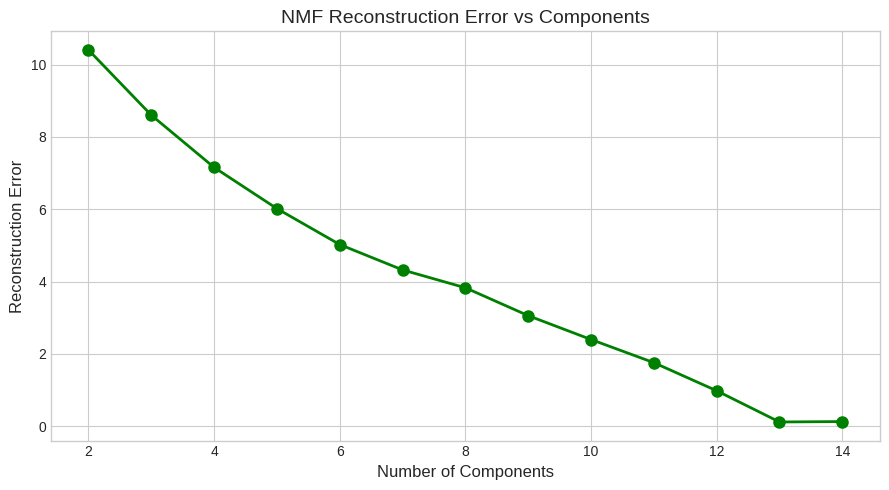

In [20]:
#Prepare matrix & fit NMF
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# NMF requires non-negative values — use MinMaxScaler instead of StandardScaler
mm_scaler = MinMaxScaler()
X_nn = mm_scaler.fit_transform(df_model[feature_cols])

# Find optimal number of components by reconstruction error
reconstruction_errors = []
components_range = range(2, 15)

for n in components_range:
    nmf = NMF(n_components=n, random_state=42, max_iter=500)
    W = nmf.fit_transform(X_nn)
    reconstruction_errors.append(nmf.reconstruction_err_)

plt.figure(figsize=(9, 5))
plt.plot(components_range, reconstruction_errors, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Reconstruction Error', fontsize=12)
plt.title('NMF Reconstruction Error vs Components', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
#Fit final NMF
# Choose n_components where reconstruction error begins to flatten
N_COMPONENTS = 8  # adjust based on your plot

nmf_model = NMF(n_components=N_COMPONENTS, random_state=42, max_iter=500)
W = nmf_model.fit_transform(X_nn)  # player representations (n_players x n_components)
H = nmf_model.components_          # feature loadings (n_components x n_features)

print(f"Player representation matrix shape: {W.shape}")
print(f"Feature loading matrix shape: {H.shape}")
print(f"Final reconstruction error: {nmf_model.reconstruction_err_:.4f}")

Player representation matrix shape: (539, 8)
Feature loading matrix shape: (8, 13)
Final reconstruction error: 3.8280


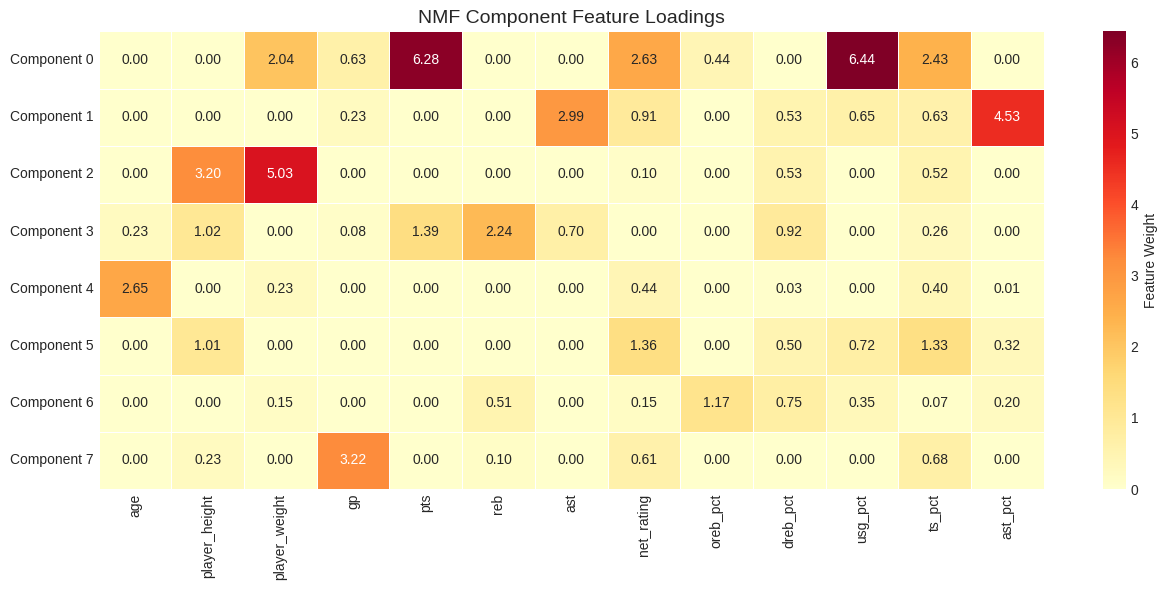

In [23]:
# inspect latent components
# See what each latent component emphasizes
components_df = pd.DataFrame(H, columns=feature_cols,
                              index=[f'Component {i}' for i in range(N_COMPONENTS)])

plt.figure(figsize=(13, 6))
sns.heatmap(components_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Feature Weight'})
plt.title('NMF Component Feature Loadings', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
#Build recommender function
# Compute cosine similarity between all player representations
similarity_matrix = cosine_similarity(W)
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df_model['player_name'].values,
    columns=df_model['player_name'].values
)

def recommend_similar_players(player_name, n=5):
    """
    Given a player name, return the n most statistically similar players
    based on NMF latent representations and cosine similarity.
    """
    if player_name not in similarity_df.index:
        print(f"Player '{player_name}' not found. Check spelling or season availability.")
        return
    
    # Sort by similarity, exclude the player themselves
    similar = (similarity_df[player_name]
               .drop(player_name)
               .sort_values(ascending=False)
               .head(n))
    
    print(f"\nTop {n} players most similar to {player_name}:\n")
    results = []
    for i, (name, score) in enumerate(similar.items(), 1):
        cluster = df_model.loc[df_model['player_name'] == name, 'archetype'].values[0]
        pts = df_model.loc[df_model['player_name'] == name, 'pts'].values[0]
        ast = df_model.loc[df_model['player_name'] == name, 'ast'].values[0]
        reb = df_model.loc[df_model['player_name'] == name, 'reb'].values[0]
        print(f"  {i}. {name:<25} sim={score:.4f} | {pts:.1f}pts {ast:.1f}ast {reb:.1f}reb | {cluster}")
        results.append({'player': name, 'similarity': score, 'archetype': cluster})
    
    return pd.DataFrame(results)

In [26]:
#Run some examples
# Try a few players across different archetypes
test_players = [
    'LeBron James',
    'Nikola Jokic',
    'Stephen Curry',
    'Kawhi Leonard'
]

for player in test_players:
    recommend_similar_players(player, n=5)
    print("-" * 60)


Top 5 players most similar to LeBron James:

  1. Paul George               sim=0.9773 | 23.8pts 5.1ast 6.1reb | Star Playmaker / Primary Ball Handler
  2. Stephen Curry             sim=0.9678 | 29.4pts 6.3ast 6.1reb | Star Playmaker / Primary Ball Handler
  3. Kawhi Leonard             sim=0.9660 | 23.8pts 3.9ast 6.5reb | Star Playmaker / Primary Ball Handler
  4. Kevin Durant              sim=0.9632 | 29.1pts 5.0ast 6.7reb | Star Playmaker / Primary Ball Handler
  5. Jimmy Butler              sim=0.9579 | 22.9pts 5.3ast 5.9reb | Star Playmaker / Primary Ball Handler
------------------------------------------------------------

Top 5 players most similar to Nikola Jokic:

  1. Giannis Antetokounmpo     sim=0.9798 | 31.1pts 5.7ast 11.8reb | Power Forward / Center
  2. Joel Embiid               sim=0.9744 | 33.1pts 4.2ast 10.2reb | Power Forward / Center
  3. Domantas Sabonis          sim=0.9724 | 19.1pts 7.3ast 12.3reb | Power Forward / Center
  4. Julius Randle             sim=0.9645

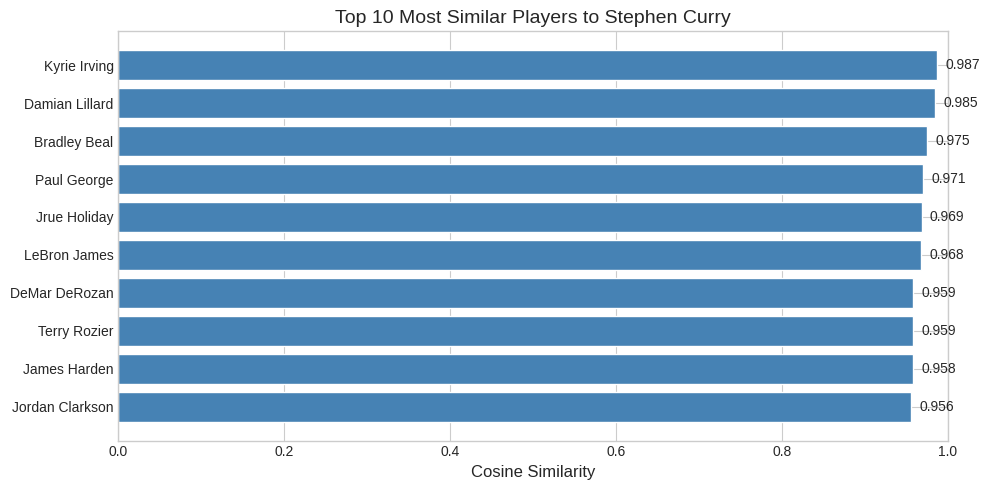

In [27]:
#Visualize one player's similarity
def plot_similarity(player_name, n=10):
    if player_name not in similarity_df.index:
        print(f"Player not found.")
        return
    
    similar = (similarity_df[player_name]
               .drop(player_name)
               .sort_values(ascending=False)
               .head(n))
    
    plt.figure(figsize=(10, 5))
    bars = plt.barh(similar.index[::-1], similar.values[::-1], color='steelblue', edgecolor='white')
    plt.xlabel('Cosine Similarity', fontsize=12)
    plt.title(f'Top {n} Most Similar Players to {player_name}', fontsize=14)
    plt.xlim(0, 1)
    
    # Add value labels
    for bar, val in zip(bars, similar.values[::-1]):
        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Visualize for your most interesting result
plot_similarity('Stephen Curry')

## Model Comparison: DBSCAN / Density-Based Clustering & Outlier Detection vs K means

K-Means forced every player into one of five buckets. That's useful for archetype 
classification, but it obscures something important: some players genuinely don't 
fit any archetype. DBSCAN (Density-Based Spatial Clustering of Applications with 
Noise) finds clusters organically based on density and crucially, labels players 
that don't belong to any cluster as outliers.

For a replacement tool, this matters. If a player is flagged as an outlier, 
there may be no true statistical twin in the league. A front office should 
know that before starting their search.

Two key parameters:
- **eps**: the neighborhood radius. Points within eps of each other are neighbors.
- **min_samples**: minimum neighbors required to form a dense region (core point).

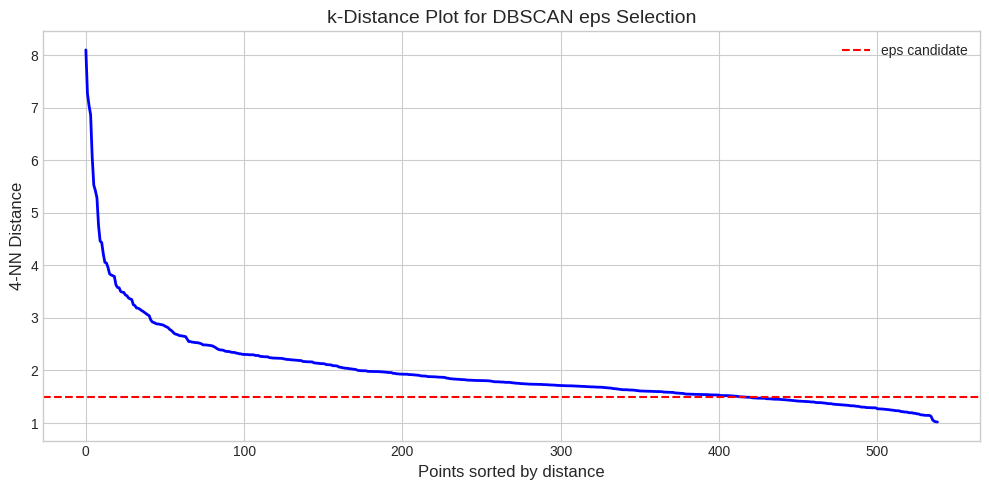


Look for the 'elbow' in this plot — the point where distance starts increasing 
sharply. That's your eps value. The red line shows our candidate.



In [29]:
#Tune eps with k-distance plot
from sklearn.neighbors import NearestNeighbors

# k-distance plot to find optimal eps
# Convention: use k = min_samples - 1
MIN_SAMPLES = 5
k = MIN_SAMPLES - 1

nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, k-1], axis=0)[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, 'b-', linewidth=2)
plt.xlabel('Points sorted by distance', fontsize=12)
plt.ylabel(f'{k}-NN Distance', fontsize=12)
plt.title('k-Distance Plot for DBSCAN eps Selection', fontsize=14)
plt.axhline(y=1.5, color='red', linestyle='--', label='eps candidate')
plt.legend()
plt.tight_layout()
plt.show()

print("""
Look for the 'elbow' in this plot — the point where distance starts increasing 
sharply. That's your eps value. The red line shows our candidate.
""")

In [37]:
#Fit DBScan
from sklearn.cluster import DBSCAN

# Fit DBSCAN — adjust eps based on k-distance plot
EPS = 2.5      # adjust based on your plot
MIN_SAMPLES = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df_model['dbscan_cluster'] = dbscan.fit_predict(X)

n_clusters = len(set(df_model['dbscan_cluster'])) - (1 if -1 in df_model['dbscan_cluster'].values else 0)
n_outliers = (df_model['dbscan_cluster'] == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Outliers flagged: {n_outliers} ({n_outliers/len(df_model)*100:.1f}% of players)")
print(f"\nCluster distribution:")
print(df_model['dbscan_cluster'].value_counts().sort_index())

Clusters found: 1
Outliers flagged: 51 (9.5% of players)

Cluster distribution:
dbscan_cluster
-1     51
 0    488
Name: count, dtype: int64


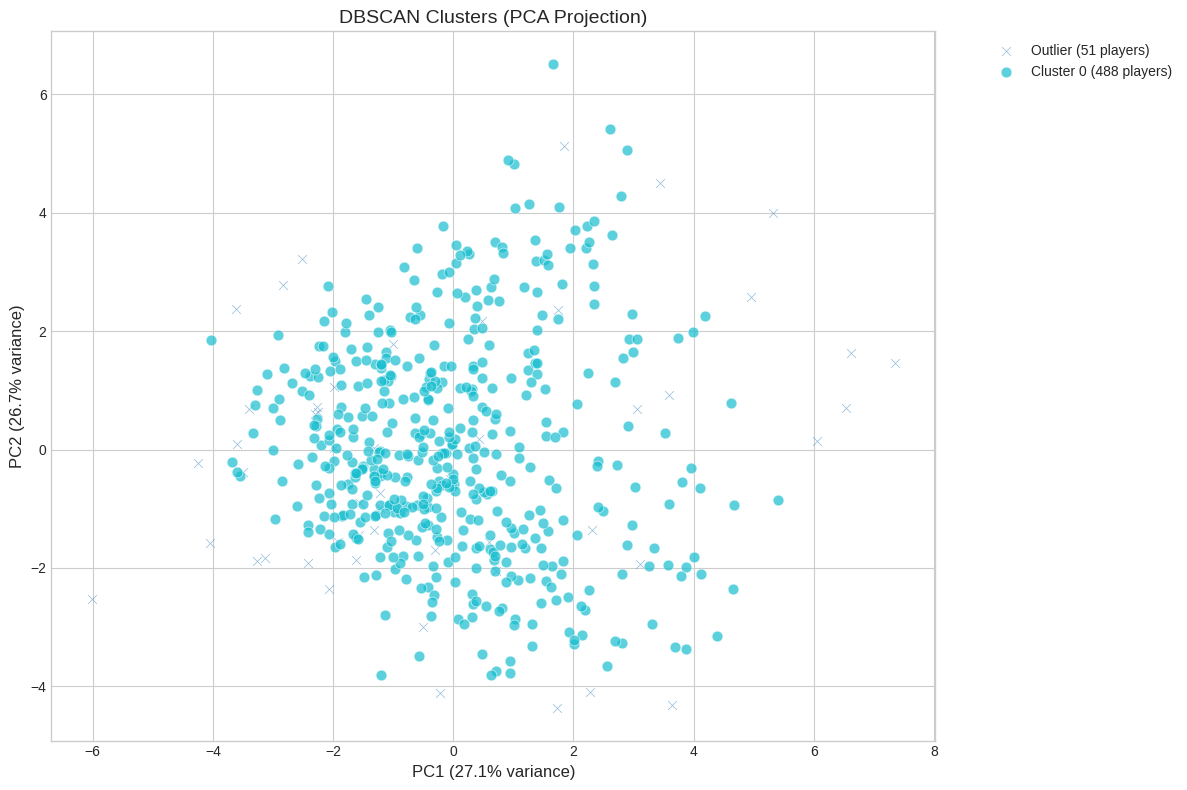

In [38]:
#Visualize DBScan Clusters
plt.figure(figsize=(12, 8))

# Plot clusters
unique_clusters = sorted(df_model['dbscan_cluster'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

for cluster_id, color in zip(unique_clusters, colors):
    mask = df_model['dbscan_cluster'] == cluster_id
    label = f'Outlier ({mask.sum()} players)' if cluster_id == -1 else f'Cluster {cluster_id} ({mask.sum()} players)'
    marker = 'x' if cluster_id == -1 else 'o'
    size = 40 if cluster_id == -1 else 60
    alpha = 0.5 if cluster_id == -1 else 0.7
    
    plt.scatter(df_model.loc[mask, 'pca1'],
                df_model.loc[mask, 'pca2'],
                c=[color], label=label,
                marker=marker, s=size, alpha=alpha,
                edgecolors='white' if cluster_id != -1 else 'none',
                linewidths=0.5)

plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('DBSCAN Clusters (PCA Projection)', fontsize=14)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [39]:
#Inspect the outliers
# Who got flagged as outliers?
outliers = df_model[df_model['dbscan_cluster'] == -1][
    ['player_name', 'pts', 'reb', 'ast', 'usg_pct', 'ts_pct', 'archetype']
].sort_values('pts', ascending=False)

print(f"=== Players Flagged as Outliers by DBSCAN ===\n")
print(outliers.to_string(index=False))

=== Players Flagged as Outliers by DBSCAN ===

            player_name  pts  reb  ast  usg_pct  ts_pct                             archetype
            Joel Embiid 33.1 10.2  4.2    0.370   0.655                Power Forward / Center
            Luka Doncic 32.4  8.6  8.0    0.368   0.609 Star Playmaker / Primary Ball Handler
  Giannis Antetokounmpo 31.1 11.8  5.7    0.373   0.605                Power Forward / Center
           LeBron James 28.9  8.3  6.8    0.322   0.583 Star Playmaker / Primary Ball Handler
        Zion Williamson 26.0  7.0  4.6    0.288   0.652                Power Forward / Center
           Nikola Jokic 24.5 11.8  9.8    0.263   0.701                Power Forward / Center
           James Harden 21.0  6.1 10.7    0.247   0.607 Star Playmaker / Primary Ball Handler
      Tyrese Haliburton 20.7  3.7 10.4    0.238   0.624 Star Playmaker / Primary Ball Handler
             Louis King 20.0  4.0  2.0    0.205   0.744              Role Player / Bench Wing
        Cade 

In [40]:
#Compare k-means vs dbscan
# How do the two clustering approaches compare?
comparison = df_model[['player_name', 'archetype', 'dbscan_cluster', 
                         'pts', 'reb', 'ast']].copy()
comparison['dbscan_label'] = comparison['dbscan_cluster'].apply(
    lambda x: 'Outlier' if x == -1 else f'Cluster {x}'
)

# Players K-Means clustered but DBSCAN flagged as outliers
interesting = comparison[comparison['dbscan_cluster'] == -1].sort_values('pts', ascending=False)
print("Players K-Means assigned an archetype but DBSCAN flagged as outliers:")
print(interesting[['player_name', 'archetype', 'pts', 'reb', 'ast']].to_string(index=False))

Players K-Means assigned an archetype but DBSCAN flagged as outliers:
            player_name                             archetype  pts  reb  ast
            Joel Embiid                Power Forward / Center 33.1 10.2  4.2
            Luka Doncic Star Playmaker / Primary Ball Handler 32.4  8.6  8.0
  Giannis Antetokounmpo                Power Forward / Center 31.1 11.8  5.7
           LeBron James Star Playmaker / Primary Ball Handler 28.9  8.3  6.8
        Zion Williamson                Power Forward / Center 26.0  7.0  4.6
           Nikola Jokic                Power Forward / Center 24.5 11.8  9.8
           James Harden Star Playmaker / Primary Ball Handler 21.0  6.1 10.7
      Tyrese Haliburton Star Playmaker / Primary Ball Handler 20.7  3.7 10.4
             Louis King              Role Player / Bench Wing 20.0  4.0  2.0
        Cade Cunningham Star Playmaker / Primary Ball Handler 19.9  6.2  6.0
       Domantas Sabonis                Power Forward / Center 19.1 12.3  7.3
      

### DBSCAN Results & Interpretation

DBSCAN found one primary cluster containing 488 players (90.5%), with 51 outliers 
(9.5%). Most NBA players occupy a continuous statistical density. There aren't multiple distinct "islands" of player types; there's one large population with stars and anomalies scattered at the edges.

The outlier list validates the model. The top-flagged players like Joel Embiid, 
Luka Doncic, Giannis Antetokounmpo, LeBron James, and Nikola Jokic are widely considered 
the most uniquely skilled players in the league. DBSCAN flagged them not because they're 
bad fits, but because no one else produces a similar statistical profile at a similar volume.

Two distinct outlier types emerge:
* **Elite outliers**: (Embiid, Luka, Giannis, LeBron, Jokic) statistically irreplaceable. 
  High pts, reb, ast simultaneously at high usage. No true replacement exists.
* **Fringe outliers**: (players with 0.0 across multiple stats) players with so few 
  minutes that their profile is statistically isolated from the main population.

### What This Means for the Replacement Tool

This is the most actionable DBSCAN output. If a front office loses an outlier-tier 
player, the NMF recommender will still return names, but the similarity scores will 
be low becasue there is no true replacement for them. DBSCAN tells you that 
explicitly, before you waste time searching.

### K-Means vs DBSCAN

| | K-Means | DBSCAN |
|---|---|---|
| Cluster shape | Spherical | Arbitrary |
| Outlier handling | Forces all points into a cluster | Explicitly flags outliers |
| Parameters | k (number of clusters) | eps, min_samples |
| Result | Every player has an archetype | Some players have no archetype |
| Best for | Archetype classification | Irreplaceability detection |

K-Means wins for day-to-day roster decisions. It's interpretable and covers every 
player. DBSCAN adds a critical layer, it tells you when you're trying to replace 
someone who can't be replaced.

## Final Conclusions

NBA front offices face a real problem: when a player gets injured or traded, 
who do you call? This project built a two-step data-driven answer to that question.

### What Each Model Contributed

**K-Means** classified every player in the league into one of five archetypes,
Power Forward/Center, Backup Big, Role Player, Star Playmaker, and Young/Developmental. 
Step one of any replacement search: know what you're replacing.

**NMF** went deeper. Rather than archetypes, it built a continuous similarity space 
where every player can be ranked against every other player. The output is a ranked 
list of statistical twins, the actual names a front office would call.

**DBSCAN** added the most honest finding of the three: some players can't be replaced. 
Joel Embiid, Luka Doncic, Giannis, LeBron, Jokic, the model flagged them as 
statistical outliers because no one else in the league produces a similar profile 
at similar volume. If you lose one of them, the NMF recommender will give you a 
list, but the similarity scores will tell the real story.

### The Bigger Picture

All three models agree on something: NBA talent is not a discrete set of buckets. 
It's a continuous spectrum, with a dense core of interchangeable role players and 
a sparse outer ring of genuinely unique contributors. The modest K-Means silhouette 
scores (peak 0.202) and DBSCAN's single primary cluster both point to the same 
conclusion: you can draw lines in this space, but the lines are fuzzy by nature.

### Limitations & What's Next

* **Single season snapshot.** The tool reflects who a player is right now. 
  Multi-season data would add trajectory, which developmental players are trending 
  toward star territory, and which stars are declining into role player profiles.
* **Stats only.** Salary, contract length, age curve, and fit with existing roster 
  construction are all missing. This is a first filter, not a final answer.
* **No positional constraints.** The recommender might suggest a center as a 
  replacement for a point guard if their stat profiles overlap. A position-aware 
  version would be more practical.

Used correctly, this is a way to make scouting faster and more defensible. Start with the data. Then watch the tape.
